In [ ]:
# Road Noise Prediction Benchmark

## Overview
This notebook presents a comparative study of machine learning and deep learning algorithms for road noise prediction.

The workflow includes:
- Data preprocessing
- Feature normalization
- Train-test splitting
- Cross-validation
- Model training and evaluation
- Prediction analysis

---

## Implemented Algorithms
- LightGBM
- XGBoost
- BiLSTM
- BiGRU
- Neural Networks (TensorFlow/Keras)

---

## Dataset
Dataset file:
- `idmt_decibels_numeric.xlsx`

Target variable:
- Road noise level (dB)

---

## Evaluation Metrics
The models are evaluated using:
- RMSE
- MAE
- R² Score

---

## Technologies
- Python
- Pandas
- NumPy
- Scikit-learn
- TensorFlow / Keras
- LightGBM
- XGBoost
- Matplotlib

---

## Contributors
- Mustafa Demetgül
- Marc Heinzelmann

---

## Notes
This notebook is intended for research and educational purposes.



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import lightgbm
import xgboost as xgb

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError, R2Score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [2]:
def display(model, name, keras=False, show_plots=False):
  #R2 plot with test data
  if keras:
    Y_pred = model.predict(X_test_keras).flatten()
  else:
    Y_pred = model.predict(X_test)

  sum_squares_residuals = sum((Y_test - Y_pred) ** 2)
  sum_squares = sum((Y_test - np.mean(Y_test)) ** 2)
  R2_variable = 1 - sum_squares_residuals / sum_squares

  if show_plots:
    plt.plot(Y_test, Y_pred, 'o', color='#00876C', alpha=0.2)
    plt.xlabel('True  values')
    plt.ylabel('Predicted values')
    x = np.sort(Y_test)
    plt.plot(x, x, color='#4664AA')
    plt.title(name)
    plt.show()

  MAE = np.mean(np.abs(Y_test - Y_pred))
  print('MAE='+str(MAE))
  MSE = np.mean((Y_test - Y_pred) ** 2)
  print('MSE='+str(MSE))
  RMSE = np.sqrt(MSE)
  print('RMSE='+str(RMSE))
  print('R2='+str(R2_variable))

  return np.array([MAE, MSE, RMSE, R2_variable])


def forecasting_chart(model, name, keras=False):
  #R2 plot with test data
  if keras:
    Y_pred = model.predict(X_test_keras).flatten()
  else:
    Y_pred = model.predict(X_test)

  indices = list(range(50))
  plt.plot(indices, Y_pred[indices], 'o', linestyle='--', linewidth=0.4, color='#00876C', alpha=0.7)
  plt.plot(indices, Y_test[indices], 'o', linestyle='--', linewidth=0.4, color='#000000', alpha=0.7)

  plt.xlabel('Index')
  plt.ylabel('decibels')
  plt.legend(['Predicted', 'True'])
  plt.title(name + str(' Forecasting Chart'))
  plt.show()


In [ ]:
### load data

#df = pd.read_excel('shuffled_octave.xlsx')
#df = df.drop(columns=['Unnamed: 0']) # drop unnecessary columns, 'Unnamed: 0' is th index


df = pd.read_excel('idmt_decibels_numeric.xlsx')
df = df.drop(columns=['file', 'Unnamed: 0', 'sample_pos'])

### shuffle data
df = df.sample(frac=1).reset_index(drop=True)

Y = df.iloc[:,-1].to_numpy()
X_temp = df.iloc[:,:-1].to_numpy()

### Scale the input
X = MinMaxScaler().fit_transform(np.reshape(X_temp, (X_temp.shape[0],-1)))

### Split dataset
splitpoint = int(X.shape[0]*0.8)
X_train, Y_train = X[:splitpoint], Y[:splitpoint]
X_test, Y_test = X[splitpoint:], Y[splitpoint:]
X_train_keras = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],-1)) # different shape for neural networks
X_test_keras = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],-1))

print(X.shape)

(17035, 9)


# LightGBM

Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[7152]	training's rmse: 4.08007	valid_0's rmse: 3.98435
MAE=2.863827679694477
MSE=16.34048646650827
RMSE=4.042336758176917
R2=0.9267317711782239
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[6472]	training's rmse: 4.05075	valid_0's rmse: 4.09945
MAE=2.8701471881249714
MSE=16.35551335317306
RMSE=4.044195019181575
R2=0.9266643929289355
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[4888]	training's rmse: 4.03434	valid_0's rmse: 4.16354
MAE=2.8671075244782034
MSE=16.358159815180677
RMSE=4.04452219862627
R2=0.9266525266002102
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[5304]	training's rmse: 4.05723	valid_0's rmse: 4.07759
MAE=2.8699257844791326
MSE=16.3868705795316
RMSE=4.048069982044727
R2=0.9265237919473939
Training until validation scor

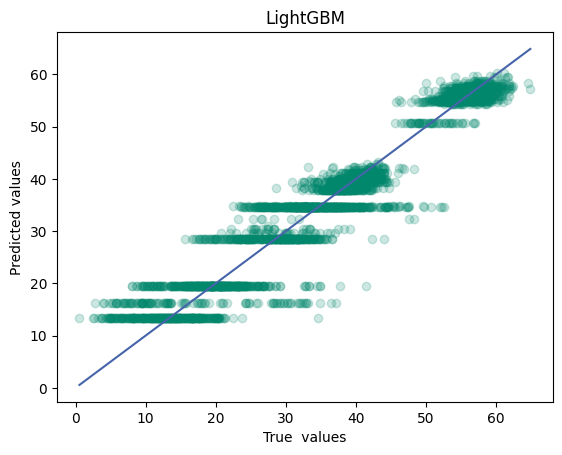

MAE=2.860306207849381
MSE=16.34927314814123
RMSE=4.043423444080675
R2=0.9266923730488115
Mean MAE: 2.8662628769252327
Mean MSE: 16.35806067250697
Mean RMSE: 4.044509480422033
Mean R2: 0.926652971140715


In [4]:
early_stopping = lightgbm.early_stopping(stopping_rounds=500)

parameters = {'objective': 'regression',
              'metric': 'rmse',
              'boosting': 'gbdt',
              'num_leaves': 27,
              'max_depth': -1,
              'feature_fraction': 0.96,
              'bagging_fraction': 0.9,
              'bagging_freq': 8,
              'learning_rate': 0.001, #0.02765
              'lambda_l1': 0.755,
              'lambda_l2': 0.796, 
              'min_data_in_leaf': 11, 
              'verbose': -1,
              'n_estimators': 10000
              }

for_evaluation = {}
mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train.shape[0]))
  X_train_temp = X_train[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  model_lgbm = lightgbm.LGBMRegressor(**parameters)
  model_lgbm.fit(X_train_temp, Y_train_temp, eval_set=[(X_val_temp, Y_val_temp), (X_train_temp, Y_train_temp)], 
                 callbacks=[lightgbm.record_evaluation(for_evaluation), early_stopping])

  mean_metrics = mean_metrics + display(model_lgbm, name='LightGBM', show_plots=(True if i==K-1 else False))

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='rmse'>

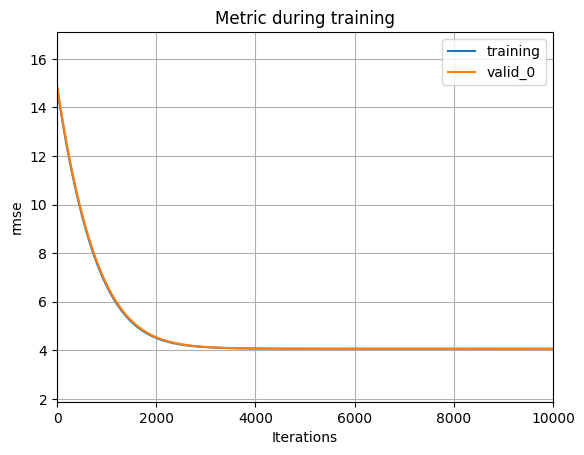

In [5]:
lightgbm.plot_metric(for_evaluation)

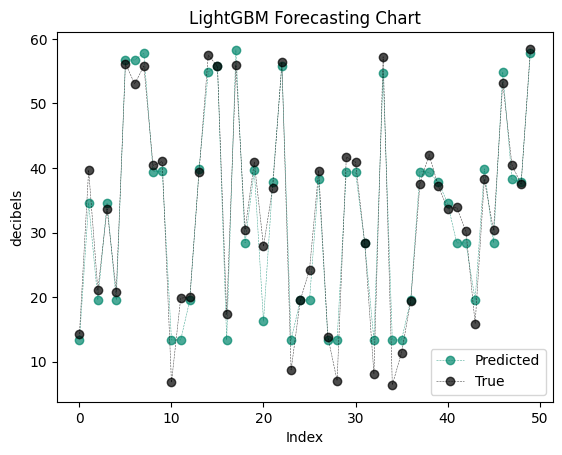

In [6]:
forecasting_chart(model_lgbm, name='LightGBM')

# XGBoost

In [7]:

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train.shape[0]))
  X_train_temp = X_train[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  model_xgb = xgb.XGBRegressor(objective ='reg:squarederror', booster='gbtree', colsample_bytree = 1.0, learning_rate = 0.005,
                max_depth = 127, alpha = 10, n_estimators = 1000, early_stopping_rounds=500)
  model_xgb.fit(X_train_temp, Y_train_temp, eval_set=[(X_val_temp, Y_val_temp)], verbose=500)

  mean_metrics = mean_metrics + display(model_xgb, name='XGBoost')

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))


[0]	validation_0-rmse:14.72660
[500]	validation_0-rmse:4.17229
[999]	validation_0-rmse:3.98269
MAE=2.8677258097137117
MSE=16.368168748865937
RMSE=4.04575935380071
R2=0.9266076480805273
[0]	validation_0-rmse:14.94466
[500]	validation_0-rmse:4.28867
[999]	validation_0-rmse:4.10794
MAE=2.875467838948079
MSE=16.403874696253016
RMSE=4.050169712030968
R2=0.9264475481025481
[0]	validation_0-rmse:14.75374
[500]	validation_0-rmse:4.29395
[999]	validation_0-rmse:4.16227
MAE=2.8703869728071396
MSE=16.373930496239222
RMSE=4.0464713635758285
R2=0.9265818132912251
[0]	validation_0-rmse:14.69764
[500]	validation_0-rmse:4.23628
[999]	validation_0-rmse:4.07950
MAE=2.8740923051731477
MSE=16.408658820869615
RMSE=4.050760276894896
R2=0.926426096823369
[0]	validation_0-rmse:14.87019
[500]	validation_0-rmse:4.25265
[999]	validation_0-rmse:4.05905
MAE=2.8649919500244336
MSE=16.37246609520917
RMSE=4.046290411625094
R2=0.9265883794402794
Mean MAE: 2.8705329753333024
Mean MSE: 16.385419771487392
Mean RMSE: 4.04

# BiLSTM

In [ ]:
model_BiLSTM = Sequential(
    [
        Bidirectional(LSTM(128, input_shape=(X_train_keras.shape[1], X_train_keras.shape[2]), return_sequences=True)),
        LeakyReLU(alpha=0.1),
        Bidirectional(LSTM(64, return_sequences=False)),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(1)
    ]
)

optimizer = Adam(learning_rate=0.01)
model_BiLSTM.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[R2Score()])

early_stopping = EarlyStopping(monitor='val_r2_score', mode='max', patience=100, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_r2_score', mode='max', factor=0.5, patience=30)

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train_keras.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train_keras.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train_keras.shape[0]))
  X_train_temp = X_train_keras[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train_keras[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  history = model_BiLSTM.fit(X_train_temp, Y_train_temp, validation_data=(X_val_temp, Y_val_temp), epochs=200, batch_size=64,
                    callbacks=[early_stopping, lr_scheduler], verbose=1) # for the actual performance graph I used 100 epochs

  mean_metrics = mean_metrics + display(model_BiLSTM, name='BiLSTM', keras=True)

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))


Epoch 1/200

107/107 [==============================] - 25s 82ms/step - loss: 379.6484 - r2_score: -0.7233 - val_loss: 221.6081 - val_r2_score: -1.5032e-04 - lr: 0.0100
Epoch 2/200
107/107 [==============================] - 6s 53ms/step - loss: 227.7137 - r2_score: -0.0336 - val_loss: 220.1101 - val_r2_score: 0.0066 - lr: 0.0100
Epoch 3/200
107/107 [==============================] - 6s 56ms/step - loss: 225.1179 - r2_score: -0.0218 - val_loss: 217.5271 - val_r2_score: 0.0183 - lr: 0.0100
Epoch 4/200
107/107 [==============================] - 6s 56ms/step - loss: 221.9257 - r2_score: -0.0073 - val_loss: 215.3174 - val_r2_score: 0.0282 - lr: 0.0100
Epoch 5/200
107/107 [==============================] - 6s 54ms/step - loss: 219.6066 - r2_score: 0.0032 - val_loss: 213.7343 - val_r2_score: 0.0354 - lr: 0.0100
Epoch 6/200
107/107 [==============================] - 7s 62ms/step - loss: 216.8150 - r2_score: 0.0159 - val_loss: 211.5130 - val_r2_score: 0.0454 - lr: 0.0100
Epoch 7/200
107/107 [=

# LSTM

In [ ]:
model_LSTM = Sequential(
    [
        LSTM(128, input_shape=(X_train_keras.shape[1], X_train_keras.shape[2]), return_sequences=True),
        LeakyReLU(alpha=0.1),
        LSTM(64, return_sequences=False),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(1)
    ]
)

optimizer = Adam(learning_rate=0.01)
model_LSTM.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[R2Score()])

early_stopping = EarlyStopping(monitor='val_r2_score', mode='max', patience=100, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_r2_score', mode='max', factor=0.5, patience=30)

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation

if(K==1):
  X_train_temp = X_train_keras
  Y_train_temp = Y_train
  X_val_temp = X_test_keras
  Y_val_temp = Y_test

  history = model_LSTM.fit(X_train_temp, Y_train_temp, validation_data=(X_val_temp, Y_val_temp), epochs=200, batch_size=64,
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

  mean_metrics = mean_metrics + display(model_LSTM, name='LSTM', keras=True)

else:
  for i in range(K):
    splitpoint1 = int(X_train_keras.shape[0]*(1/K)*i)
    splitpoint2 = int(X_train_keras.shape[0]*(1/K)*(i+1))
    indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train_keras.shape[0]))
    X_train_temp = X_train_keras[indices]
    Y_train_temp = Y_train[indices]
    X_val_temp = X_train_keras[splitpoint1:splitpoint2]
    Y_val_temp = Y_train[splitpoint1:splitpoint2]

    history = model_LSTM.fit(X_train_temp, Y_train_temp, validation_data=(X_val_temp, Y_val_temp), epochs=200, batch_size=64,
                      callbacks=[early_stopping, lr_scheduler], verbose=1)

    mean_metrics = mean_metrics + display(model_LSTM, name='LSTM', keras=True)

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))

Epoch 1/200
213/213 [==============================] - 21s 41ms/step - loss: 400.2126 - r2_score: -0.8113 - val_loss: 223.0841 - val_r2_score: -2.7442e-04 - lr: 0.0100
Epoch 2/200
213/213 [==============================] - 6s 30ms/step - loss: 233.4580 - r2_score: -0.0566 - val_loss: 223.0853 - val_r2_score: -2.7978e-04 - lr: 0.0100
Epoch 3/200
213/213 [==============================] - 6s 30ms/step - loss: 234.7855 - r2_score: -0.0626 - val_loss: 223.0308 - val_r2_score: -3.5405e-05 - lr: 0.0100
Epoch 4/200
213/213 [==============================] - 9s 43ms/step - loss: 232.4996 - r2_score: -0.0523 - val_loss: 223.0772 - val_r2_score: -2.4354e-04 - lr: 0.0100
Epoch 5/200
213/213 [==============================] - 9s 42ms/step - loss: 233.1459 - r2_score: -0.0552 - val_loss: 223.0751 - val_r2_score: -2.3413e-04 - lr: 0.0100
Epoch 6/200
213/213 [==============================] - 7s 33ms/step - loss: 230.0700 - r2_score: -0.0413 - val_loss: 223.1335 - val_r2_score: -4.9603e-04 - lr: 0.01

# BiGRU

In [10]:
model_BiGRU = Sequential(
    [
        Bidirectional(GRU(128, input_shape=(X_train_keras.shape[1], X_train_keras.shape[2]), return_sequences=True)),
        LeakyReLU(alpha=0.1),
        Bidirectional(GRU(64, return_sequences=False)),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(1)
    ]
)

optimizer = Adam(learning_rate=0.006)
model_BiGRU.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[R2Score()])

early_stopping = EarlyStopping(monitor='val_r2_score', mode='max', patience=100, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_r2_score', mode='max', factor=0.5, patience=50)

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train_keras.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train_keras.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train_keras.shape[0]))
  X_train_temp = X_train_keras[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train_keras[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  history = model_BiGRU.fit(X_train_temp, Y_train_temp, validation_data=(X_val_temp, Y_val_temp), epochs=100, batch_size=64,
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

  mean_metrics = mean_metrics + display(model_BiGRU, name='BiGRU', keras=True)

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))

Epoch 1/100
171/171 [==============================] - 18s 47ms/step - loss: 361.6577 - r2_score: -0.6330 - val_loss: 218.8801 - val_r2_score: 1.7881e-06 - lr: 0.0060
Epoch 2/100
171/171 [==============================] - 5s 31ms/step - loss: 228.3350 - r2_score: -0.0310 - val_loss: 219.1336 - val_r2_score: -0.0012 - lr: 0.0060
Epoch 3/100
171/171 [==============================] - 5s 31ms/step - loss: 227.2615 - r2_score: -0.0262 - val_loss: 219.9400 - val_r2_score: -0.0048 - lr: 0.0060
Epoch 4/100
171/171 [==============================] - 5s 31ms/step - loss: 228.0414 - r2_score: -0.0297 - val_loss: 219.3394 - val_r2_score: -0.0021 - lr: 0.0060
Epoch 5/100
171/171 [==============================] - 5s 31ms/step - loss: 228.1437 - r2_score: -0.0302 - val_loss: 219.0870 - val_r2_score: -9.4366e-04 - lr: 0.0060
Epoch 6/100
171/171 [==============================] - 5s 32ms/step - loss: 220.2082 - r2_score: 0.0057 - val_loss: 193.0935 - val_r2_score: 0.1178 - lr: 0.0060
Epoch 7/100
171/

# GRU

In [ ]:
model_GRU = Sequential(
    [
        GRU(128, input_shape=(X_train_keras.shape[1], X_train_keras.shape[2]), return_sequences=True),
        LeakyReLU(alpha=0.1),
        GRU(64, return_sequences=False),
        LeakyReLU(alpha=0.2),
        Dropout(0.3),
        Dense(1)
    ]
)

optimizer = Adam(learning_rate=0.01)
model_GRU.compile(optimizer=optimizer, loss='mean_squared_error', metrics=[R2Score()])

early_stopping = EarlyStopping(monitor='val_r2_score', mode='max', patience=100, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_r2_score', mode='max', factor=0.5, patience=20)

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train_keras.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train_keras.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train_keras.shape[0]))
  X_train_temp = X_train_keras[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train_keras[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  history = model_GRU.fit(X_train_temp, Y_train_temp, validation_data=(X_val_temp, Y_val_temp), epochs=200, batch_size=64,
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

  mean_metrics = mean_metrics + display(model_GRU, name='GRU', keras=True)

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))

Epoch 1/200
107/107 [==============================] - 9s 38ms/step - loss: 545.0349 - r2_score: -1.4740 - val_loss: 232.7193 - val_r2_score: -0.0503 - lr: 0.0100
Epoch 2/200
107/107 [==============================] - 3s 27ms/step - loss: 236.3521 - r2_score: -0.0728 - val_loss: 221.5759 - val_r2_score: -4.8876e-06 - lr: 0.0100
Epoch 3/200
107/107 [==============================] - 3s 27ms/step - loss: 234.8655 - r2_score: -0.0661 - val_loss: 221.6189 - val_r2_score: -1.9896e-04 - lr: 0.0100
Epoch 4/200
107/107 [==============================] - 3s 28ms/step - loss: 234.3860 - r2_score: -0.0639 - val_loss: 221.6189 - val_r2_score: -1.9896e-04 - lr: 0.0100
Epoch 5/200
107/107 [==============================] - 3s 28ms/step - loss: 232.4695 - r2_score: -0.0552 - val_loss: 221.6115 - val_r2_score: -1.6558e-04 - lr: 0.0100
Epoch 6/200
107/107 [==============================] - 3s 28ms/step - loss: 232.9103 - r2_score: -0.0572 - val_loss: 221.5812 - val_r2_score: -2.8610e-05 - lr: 0.0100
Ep

# Linear Regression

In [12]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

mean_metrics = np.array([0,0,0,0])
K=5 # K-fold cross validation
for i in range(K):
  splitpoint1 = int(X_train_keras.shape[0]*(1/K)*i)
  splitpoint2 = int(X_train_keras.shape[0]*(1/K)*(i+1))
  indices = list(range(splitpoint1)) + list(range(splitpoint2, X_train_keras.shape[0]))
  X_train_temp = X_train[indices]
  Y_train_temp = Y_train[indices]
  X_val_temp = X_train_keras[splitpoint1:splitpoint2]
  Y_val_temp = Y_train[splitpoint1:splitpoint2]

  model_linear = linear_model.LinearRegression()
  model_linear.fit(X_train_temp, Y_train_temp)

  mean_metrics = mean_metrics + display(model_linear, name='Linear Regression')

mean_metrics = mean_metrics/K
print("Mean MAE: " + str(mean_metrics[0]))
print("Mean MSE: " + str(mean_metrics[1]))
print("Mean RMSE: " + str(mean_metrics[2]))
print("Mean R2: " + str(mean_metrics[3]))

MAE=3.4073193754505664
MSE=22.587359814764238
RMSE=4.7526161021866935
R2=0.8987217515965684
MAE=3.401488155039289
MSE=22.549312018270975
RMSE=4.7486115884825715
R2=0.8988923520658594
MAE=3.4033522495651516
MSE=22.55312961091309
RMSE=4.749013540822251
R2=0.8988752345674409
MAE=3.4004318176512425
MSE=22.550368257934604
RMSE=4.748722802810731
R2=0.8988876160496142
MAE=3.4029307007905762
MSE=22.588337525282792
RMSE=4.7527189613191725
R2=0.8987173676929349
Mean MAE: 3.403104459699365
Mean MSE: 22.56570144543314
Mean RMSE: 4.750336599124283
Mean R2: 0.8988188643944837
